<a href="https://colab.research.google.com/github/axghata/undergraduate-coursework/blob/main/Simple_Regression_Analyze_for_Motor_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Kilometres   -0.121815
Zone         -0.103650
Bonus         0.118027
Make          0.243910
Insured       0.933215
Claims        0.995401
Payment       1.000000
Name: Payment, dtype: float64


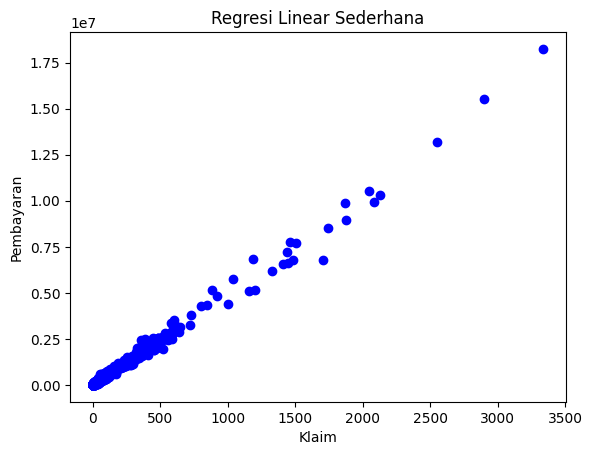

In [ ]:

#import dataset
dataset = pd.read_csv('SwedishMotorInsurance.csv')
cleaned_data = dataset.dropna()

#variabel regresi
A = cleaned_data[['Claims']]
B = cleaned_data[['Payment']]

#Plot Scatter
plt.scatter(A, B, color='blue')
plt.title('Regresi Linear Sederhana')
plt.xlabel('Klaim')
plt.ylabel('Pembayaran')

#Korelasi
correl = cleaned_data.corr()
print(correl['Payment'])

In [ ]:
#Standarisasi Data
scaler = StandardScaler()
standardized_data = scaler.fit_transform(cleaned_data)
standardized_data = pd.DataFrame(standardized_data,
columns=cleaned_data.columns)
print("\nData yang Distandarisasi:\n", standardized_data.head())


Data yang Distandarisasi:
    Kilometres      Zone     Bonus      Make   Insured    Claims   Payment
0   -1.413117 -1.499329 -1.507454 -1.541525 -0.112800  0.277622  0.132608
1   -1.413117 -1.499329 -1.507454 -1.155123 -0.180916 -0.163219 -0.207483
2   -1.413117 -1.499329 -1.507454 -0.768721 -0.180261 -0.192939 -0.237465
3   -1.413117 -1.499329 -1.507454 -0.382319  0.034965  0.356875  0.161788
4   -1.413117 -1.499329 -1.507454  0.390484 -0.108823  0.025005 -0.085016


After performing data standardization, the next step is to identify and remove outliers so that each data point influences the regression equation proportionally, thereby making predictions using the linear regression equation more accurate and valid. Outliers can be identified by determining the upper and lower bounds of each variable, which is done by first determining the quantile values of the variables. The results of the outlier identification for the variables used can be seen above.


In [ ]:
#Mencari Outliers
print("Kolom sebelum drop:", standardized_data.columns)

# Daftar kolom yang ingin dihapus
cols_to_drop = ['Kilometres', 'Zone', 'Bonus', 'Make', 'Insured']

# Periksa dan hanya hapus kolom yang ada dalam DataFrame
existing_cols_to_drop = [col for col in cols_to_drop if col in standardized_data.columns]

# Hapus kolom yang ada dalam daftar existing_cols_to_drop
standardized_data = standardized_data.drop(existing_cols_to_drop, axis=1)

# Cetak kolom setelah penghapusan untuk verifikasi
print("Kolom setelah drop:", standardized_data.columns)

# Melanjutkan proses mencari outlier
q1 = standardized_data.quantile(0.25)
q3 = standardized_data.quantile(0.75)
IQR = q3 - q1
print("Q1:\n", q1)
print("Q3:\n", q3)
print("IQR:\n", IQR)


Kolom sebelum drop: Index(['Kilometres', 'Zone', 'Bonus', 'Make', 'Insured', 'Claims', 'Payment'], dtype='object')
Kolom setelah drop: Index(['Claims', 'Payment'], dtype='object')
Q1:
 Claims    -0.252378
Payment   -0.249948
Name: 0.25, dtype: float64
Q3:
 Claims    -0.153313
Payment   -0.142630
Name: 0.75, dtype: float64
IQR:
 Claims     0.099065
Payment    0.107317
dtype: float64


After obtaining the outlier values and the outlier range, the outliers are then handled by replacing them with the median value of the data.

In [ ]:
#Penanganan Outliers
q1c = standardized_data['Claims'].quantile(0.25)
q3c = standardized_data['Claims'].quantile(0.75)
IQRc = q3c - q1c
lower_boundc = q1c - 1.5 * IQRc
upper_boundc = q3c + 1.5 * IQRc

q1p = standardized_data['Payment'].quantile(0.25)
q3p = standardized_data['Payment'].quantile(0.75)
IQRp = q3p - q1p
lower_boundp = q1p - 1.5 * IQRp
upper_boundp = q3p + 1.5 * IQRp

df_imputed = standardized_data.copy()
df_imputed['Claims'].loc[(standardized_data['Claims'] < lower_boundc) | (standardized_data['Claims'] > upper_boundc)] = standardized_data['Claims'].median()
df_imputed['Payment'].loc[(standardized_data['Payment'] < lower_boundp) | (standardized_data['Payment'] > upper_boundp)] = standardized_data['Payment'].median()
print(df_imputed)

        Claims   Payment
0    -0.232565 -0.225967
1    -0.163219 -0.207483
2    -0.192939 -0.237465
3    -0.232565 -0.225967
4    -0.232565 -0.085016
...        ...       ...
2172 -0.257331 -0.252879
2173 -0.257331 -0.252879
2174 -0.252378 -0.251931
2175 -0.257331 -0.252879
2176 -0.178079 -0.142630

[2177 rows x 2 columns]


/tmp/ipykernel_1031/1131876511.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_imputed['Claims'].loc[(standardized_data['Claims'] < lower_boundc) | (standardized_data['Claims'] > upper_boundc)] = standardized_data['Claims'].median()


In [ ]:
#Penentuan Variabel Regresi
X = df_imputed[['Claims']]
Y = df_imputed[['Payment']]

In [ ]:
#Data Train dan Data Test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

#Model Regresi
model = LinearRegression()
model.fit(X_train, Y_train)

# Membuat prediksi menggunakan data uji
Y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# Menghitung nilai RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 0.00147711213633725
Mean Absolute Error: 0.019605888209790638
R2 Score: 0.4930135863338324
Root Mean Squared Error: 0.03843321657547349


After data preprocessing, the next step is to build a simple linear regression model by splitting the data into a 20% test set and an 80% training set.

After the analysis, we obtained an MSE of 0.001, an MAE of 0.02, and an RMSE of 0.04, indicating that the error rate in the model used is very small, so it can be concluded that the regression model used fits the given data very well.

 The R² value of the model, which is close to 50%, indicates that the independent variables used are able to explain the dependent variables—in this case, “Claims” and “Payment”—for nearly 50% of the 2,177 data points used, meaning the remainder is explained by other variables. This demonstrates that the simple linear regression model used is capable of explaining the dependent variables quite well.

In [ ]:
#Koefisien parameter regresi

a = model.intercept_
b = model.coef_

print("Konstanta:", a)
print("Koefisien X:", b)

Konstanta: [-0.02761779]
Koefisien X: [[0.84478355]]


After determining how well the model performs based on the metric values, the next step is to determine the regression parameter coefficients. The regression model equation is as follows:

Y = -0.02762 + 0.8448X

Where Y is the dependent variable “Payment” and X is the independent variable “Claim.” Based on this equation, the relationship can be explained as follows:

If there is no increase in the Claims value (X = 0), then the Payment value will remain constant at -0.02762.

For every 1 unit increase in the Claims value, the Payment value will increase by 0.8448 units.

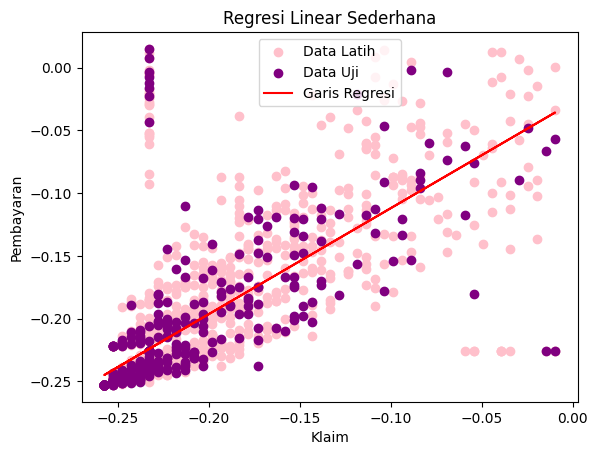

In [ ]:
#plot data
plt.scatter(X_train, Y_train, color='pink', label='Data Latih')
plt.scatter(X_test, Y_test, color='purple', label='Data Uji')
plt.plot(X_train, model.predict(X_train), color='red', label='Garis Regresi')
plt.title('Regresi Linear Sederhana')
plt.xlabel('Klaim')
plt.ylabel('Pembayaran')
plt.legend()
plt.show()